<a href="https://colab.research.google.com/github/Durgaprasad1903/e2e-ml-project/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
iris = load_iris()

In [3]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [6]:
X = pd.DataFrame(iris.data, columns = iris.feature_names)

In [7]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
y = pd.DataFrame(iris.target, columns = [ 'species'])

In [13]:
y.head()

,species
0,0
1,0
2,0
3,0
4,0


In [14]:
y.species.unique()

array([0, 1, 2])

In [26]:
y.species.replace({0:'setosa',1:'versicolor',2:'virginica'},inplace = True)

In [27]:
y.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [28]:
df = pd.concat([X,y], axis = 1)

In [29]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


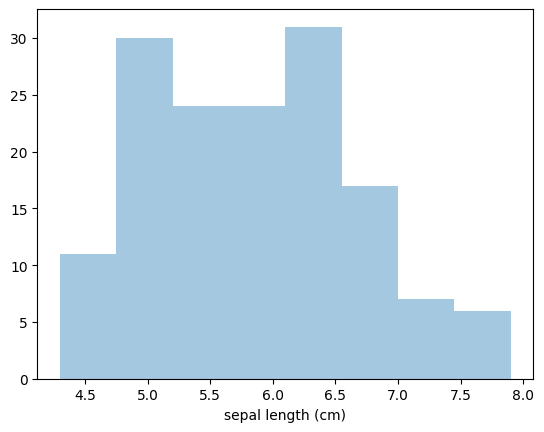

In [41]:
sns.distplot(df['sepal length (cm)'],kde = False);

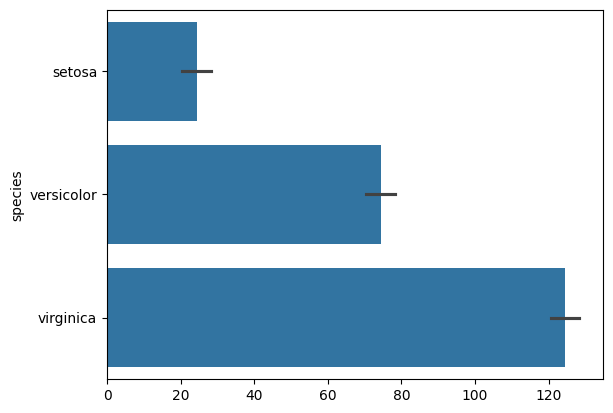

In [42]:
sns.barplot(df['species']);

In [44]:
df.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [45]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [47]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X[:] = scaler.fit_transform(X)

In [48]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


In [56]:
from sklearn.decomposition import PCA
pca = PCA(0.99)
Xpca = pca.fit_transform(X)

In [53]:
X = pd.DataFrame(Xpca, columns = ['PC1','PC2'])

In [55]:
X.head()

,PC1,PC2
0,-0.630703,0.107578
1,-0.622905,-0.104260
2,-0.669520,-0.051417
3,-0.654153,-0.102885
4,-0.648788,0.133488


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [60]:
X_train.shape,X_test.shape

((120, 2), (30, 2))

In [77]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

In [80]:
def kfold(estimator,inp,tar):
  return cross_val_score(estimator,inp,tar).mean() * 100

In [81]:
kfold(LogisticRegression(),X_train,y_train)

np.float64(86.66666666666669)

In [82]:
kfold(RandomForestClassifier(),X_train,y_train)

np.float64(95.0)

In [83]:
kfold(SVC(),X_train,y_train)

np.float64(95.83333333333334)

In [85]:
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(SVC(),{
    'C' : [0.5 , 1,2,3]
})
clf.fit(X_train,y_train)

GridSearchCV(estimator=SVC(), param_grid={'C': [0.5, 1, 2, 3]})

In [86]:
clf_df = pd.DataFrame(clf.cv_results_)

In [84]:
model = SVC()

NameError: name 'svc' is not defined